## Preparacion del entorno

Importacion de librerias necesarias para la evaluacion.

In [12]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Configuracion

Definicion de rutas y parametros para la evaluacion.

In [13]:
models_dir = Path('trained_models')
models = ['yolov8n', 'yolov8s', 'yolov8m']
class_names = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

test_csv = 'dataset/test_subset.csv'
test_dir = Path('dataset/test')
yaml_path = 'yolo_dataset/data.yaml'

results = {}

## Carga de modelos y evaluacion

Carga de los modelos entrenados y calculo de metricas principales.

In [14]:
for model_name in models:
    model_path = models_dir / f'{model_name}_best.pt'
    
    if not model_path.exists():
        print(f"Modelo {model_name} no encontrado")
        continue
    
    model = YOLO(str(model_path))
    
    metrics = model.val(data=yaml_path, split='val')
    
    results[model_name] = {
        'metrics': metrics,
        'model': model
    }
    
    print(f"\nModelo: {model_name}")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall: {metrics.box.mr:.4f}")

Ultralytics 8.3.235 🚀 Python-3.12.1 torch-2.9.1+cu128 CPU (Intel Xeon Platinum 8370C CPU @ 2.80GHz)
Model summary (fused): 72 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 128.5±69.7 MB/s, size: 463.8 KB)
val: Scanning /workspaces/DeepLearning/yolo_dataset/val/labels... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 644.6it/s 0.1s0.1s
val: New cache created: /workspaces/DeepLearning/yolo_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.3s/it 16.4s4.0s
                   all         80         80      0.509      0.652      0.608      0.594
                   MEL         10         10      0.301        0.8      0.558      0.542
                    NV         10         10      0.552        0.4        0.6      0.597
                   BCC         10         10      0.376        0.8      0.425      0.418
                    AK         10         10      0.482        0.7      0.663      0.645
                   BKL         10         10      0.271        0.5      0.475      0.463
                    DF      

## Predicciones individuales

Generacion de predicciones para cada imagen del conjunto de test.

In [ ]:
def get_predictions_per_class(model, test_dir, test_csv):
    df_test = pd.read_csv(test_csv)
    
    predictions = []
    ground_truth = []
    
    for _, row in df_test.iterrows():
        img_path = test_dir / (row['image'] + '.jpg')
        
        if img_path.exists():
            result = model(str(img_path), verbose=False)[0]
            
            if len(result.boxes) > 0:
                pred_class = int(result.boxes[0].cls[0])
                predictions.append(pred_class)
            else:
                predictions.append(-1)
            
            true_class = class_names.index(row['clase'])
            ground_truth.append(true_class)
    
    return np.array(predictions), np.array(ground_truth)

predictions_dict = {}
for model_name in models:
    if model_name in results:
        preds, gt = get_predictions_per_class(results[model_name]['model'], test_dir, test_csv)
        predictions_dict[model_name] = {'predictions': preds, 'ground_truth': gt}
        print(f"{model_name}: {len(preds)} predicciones generadas")

## Matriz de confusion

Visualizacion de las matrices de confusion para cada modelo.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Matrices de Confusion', fontsize=16)

for idx, model_name in enumerate(models):
    if model_name in predictions_dict:
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        preds_valid = preds[valid_idx]
        gt_valid = gt[valid_idx]
        
        cm = confusion_matrix(gt_valid, preds_valid)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx])
        axes[idx].set_title(f'{model_name}')
        axes[idx].set_ylabel('Etiqueta Real')
        axes[idx].set_xlabel('Etiqueta Predicha')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Reporte de clasificacion

Metricas detalladas por clase para cada modelo.

In [ ]:
for model_name in models:
    if model_name in predictions_dict:
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        preds_valid = preds[valid_idx]
        gt_valid = gt[valid_idx]
        
        print(f"\n{'='*60}")
        print(f"Reporte de clasificacion - {model_name}")
        print(f"{'='*60}\n")
        print(classification_report(gt_valid, preds_valid, target_names=class_names))
        print(f"Accuracy: {accuracy_score(gt_valid, preds_valid):.4f}")

## Comparacion de rendimiento

Comparacion de metricas entre los tres modelos.

In [ ]:
metrics_comparison = {
    'Model': [],
    'mAP50': [],
    'mAP50-95': [],
    'Precision': [],
    'Recall': [],
    'Accuracy': []
}

for model_name in models:
    if model_name in results and model_name in predictions_dict:
        metrics = results[model_name]['metrics']
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        acc = accuracy_score(gt[valid_idx], preds[valid_idx])
        
        metrics_comparison['Model'].append(model_name)
        metrics_comparison['mAP50'].append(metrics.box.map50)
        metrics_comparison['mAP50-95'].append(metrics.box.map)
        metrics_comparison['Precision'].append(metrics.box.mp)
        metrics_comparison['Recall'].append(metrics.box.mr)
        metrics_comparison['Accuracy'].append(acc)

df_comparison = pd.DataFrame(metrics_comparison)
print("\nComparacion de metricas:")
print(df_comparison.to_string(index=False))

## Visualizacion comparativa

Graficas de barras para comparar las metricas entre modelos.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparacion de metricas entre modelos', fontsize=16)

metrics_to_plot = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].bar(df_comparison['Model'], df_comparison[metric], color=colors)
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel('Score')
    axes[row, col].set_ylim(0, 1)
    axes[row, col].grid(True, alpha=0.3)
    
    for i, v in enumerate(df_comparison[metric]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Exportacion de resultados

Guardado de las metricas en formato CSV.

In [ ]:
df_comparison.to_csv('evaluation_results.csv', index=False)
print("\nResultados guardados en evaluation_results.csv")

In [ ]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## Configuracion de modelos

Carga de los modelos entrenados y configuracion del conjunto de test.

In [ ]:
models_dir = Path('trained_models')
models = ['yolov8n', 'yolov8s', 'yolov8m']
class_names = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']

test_csv = 'dataset/test_subset.csv'
test_dir = Path('dataset/test')
yaml_path = 'yolo_dataset/data.yaml'

results = {}

## Evaluacion de modelos

Ejecucion de predicciones y calculo de metricas para cada modelo.

In [ ]:
for model_name in models:
    model_path = models_dir / f'{model_name}_best.pt'
    
    if not model_path.exists():
        print(f"Modelo {model_name} no encontrado")
        continue
    
    model = YOLO(str(model_path))
    
    metrics = model.val(data=yaml_path, split='val')
    
    results[model_name] = {
        'metrics': metrics,
        'model': model
    }
    
    print(f"Modelo: {model_name}")
    print(f"mAP50: {metrics.box.map50:.4f}")
    print(f"mAP50-95: {metrics.box.map:.4f}")
    print(f"Precision: {metrics.box.mp:.4f}")
    print(f"Recall: {metrics.box.mr:.4f}")

Modelo yolov8n no encontrado en modelos_entrenados/yolov8n_best.pt
Modelo yolov8s no encontrado en modelos_entrenados/yolov8s_best.pt
Modelo yolov8m no encontrado en modelos_entrenados/yolov8m_best.pt


## Predicciones en imagenes individuales

Generacion de predicciones clase por clase para analisis detallado.

In [ ]:
def get_predictions_per_class(model, test_dir, test_csv):
    df_test = pd.read_csv(test_csv)
    
    predictions = []
    ground_truth = []
    
    for _, row in df_test.iterrows():
        img_path = test_dir / (row['image'] + '.jpg')
        
        if img_path.exists():
            result = model(str(img_path), verbose=False)[0]
            
            if len(result.boxes) > 0:
                pred_class = int(result.boxes[0].cls[0])
                predictions.append(pred_class)
            else:
                predictions.append(-1)
            
            true_class = class_names.index(row['clase'])
            ground_truth.append(true_class)
    
    return np.array(predictions), np.array(ground_truth)

predictions_dict = {}
for model_name in models:
    if model_name in results:
        preds, gt = get_predictions_per_class(results[model_name]['model'], test_dir, test_csv)
        predictions_dict[model_name] = {'predictions': preds, 'ground_truth': gt}

## Matriz de confusión

Visualizacion de las matrices de confusion para cada modelo.

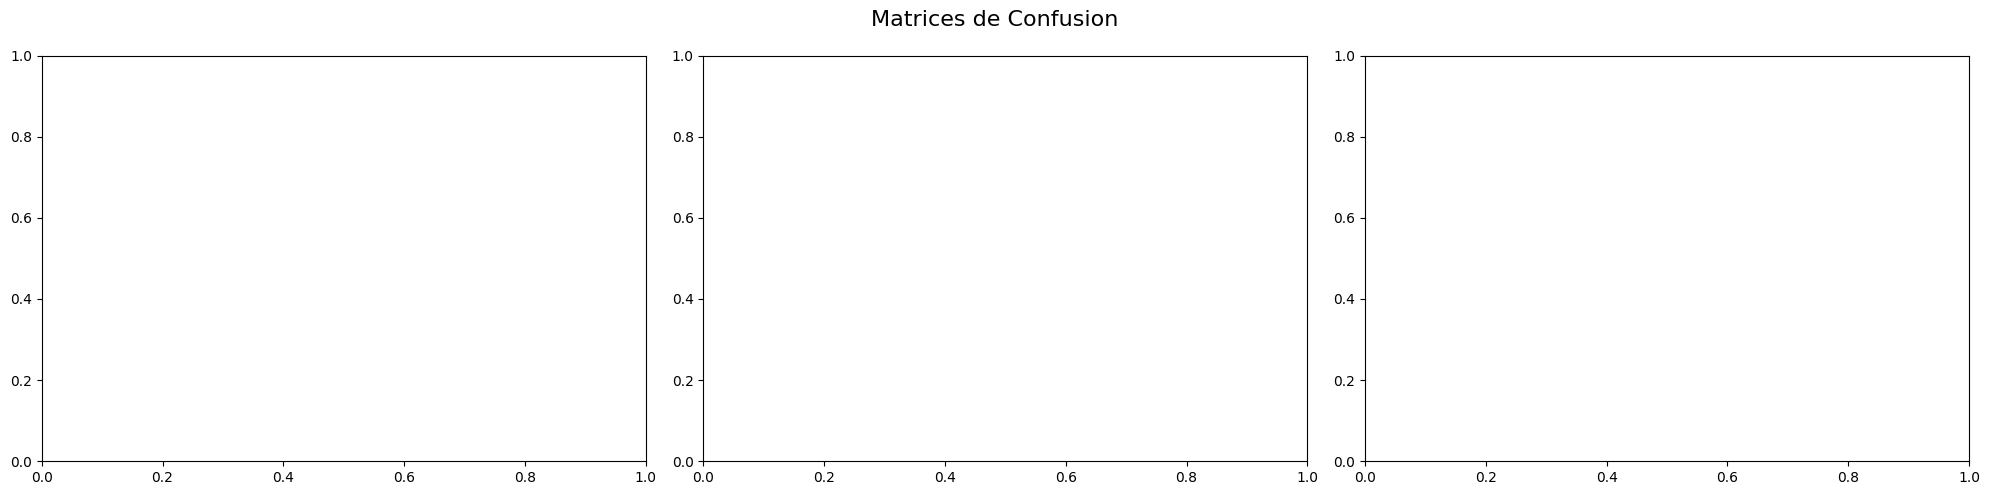

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Matrices de Confusion', fontsize=16)

for idx, model_name in enumerate(models):
    if model_name in predictions_dict:
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        preds_valid = preds[valid_idx]
        gt_valid = gt[valid_idx]
        
        cm = confusion_matrix(gt_valid, preds_valid)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=class_names, yticklabels=class_names,
                    ax=axes[idx])
        axes[idx].set_title(f'{model_name}')
        axes[idx].set_ylabel('True Label')
        axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Métricas por clase

Reporte detallado de precision, recall y F1-score por clase para cada modelo.

In [ ]:
for model_name in models:
    if model_name in predictions_dict:
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        preds_valid = preds[valid_idx]
        gt_valid = gt[valid_idx]
        
        print(f"\n{'='*60}")
        print(f"Reporte de clasificacion - {model_name}")
        print(f"{'='*60}\n")
        print(classification_report(gt_valid, preds_valid, target_names=class_names))
        print(f"Accuracy: {accuracy_score(gt_valid, preds_valid):.4f}")

## Comparacion de rendimiento

Graficas comparativas de las metricas principales entre los tres modelos.

Empty DataFrame
Columns: [Model, mAP50, mAP50-95, Precision, Recall, Accuracy]
Index: []


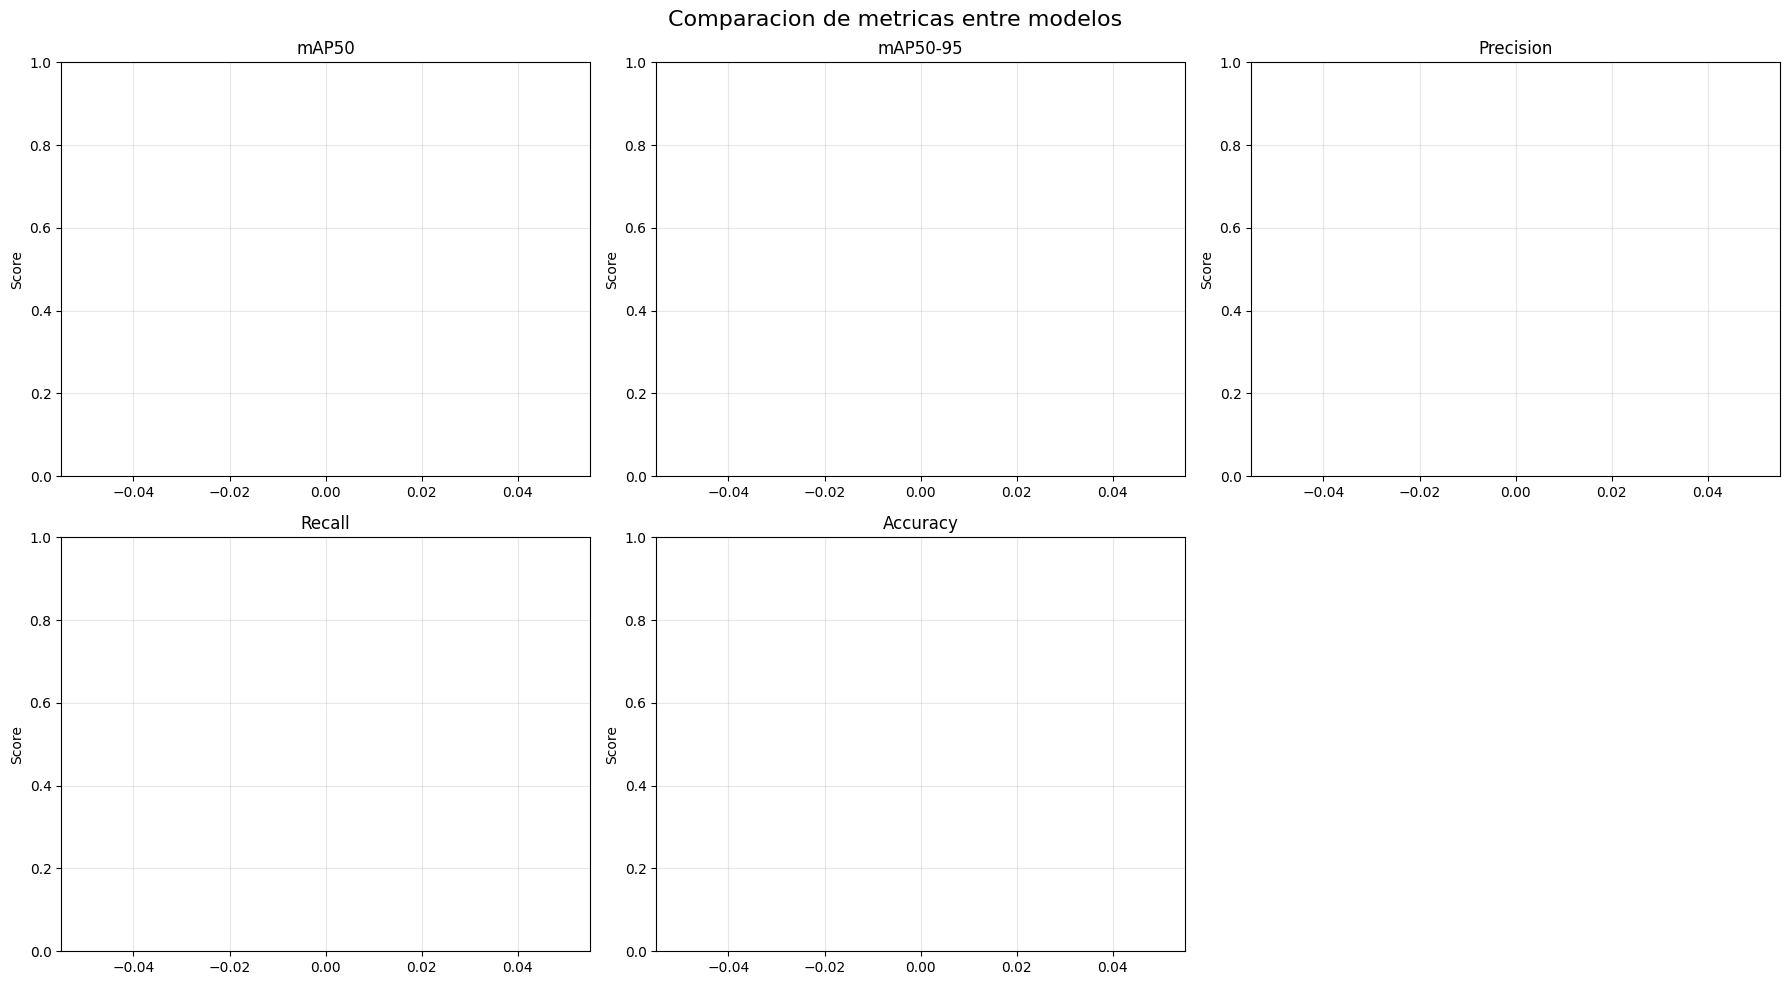

In [ ]:
metrics_comparison = {
    'Model': [],
    'mAP50': [],
    'mAP50-95': [],
    'Precision': [],
    'Recall': [],
    'Accuracy': []
}

for model_name in models:
    if model_name in results and model_name in predictions_dict:
        metrics = results[model_name]['metrics']
        preds = predictions_dict[model_name]['predictions']
        gt = predictions_dict[model_name]['ground_truth']
        
        valid_idx = preds != -1
        acc = accuracy_score(gt[valid_idx], preds[valid_idx])
        
        metrics_comparison['Model'].append(model_name)
        metrics_comparison['mAP50'].append(metrics.box.map50)
        metrics_comparison['mAP50-95'].append(metrics.box.map)
        metrics_comparison['Precision'].append(metrics.box.mp)
        metrics_comparison['Recall'].append(metrics.box.mr)
        metrics_comparison['Accuracy'].append(acc)

df_comparison = pd.DataFrame(metrics_comparison)
print(df_comparison.to_string(index=False))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparacion de metricas entre modelos', fontsize=16)

metrics_to_plot = ['mAP50', 'mAP50-95', 'Precision', 'Recall', 'Accuracy']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].bar(df_comparison['Model'], df_comparison[metric], color=colors)
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel('Score')
    axes[row, col].set_ylim(0, 1)
    axes[row, col].grid(True, alpha=0.3)
    
    for i, v in enumerate(df_comparison[metric]):
        axes[row, col].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom')

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Guardado de resultados

Exportacion de las metricas a un archivo CSV para analisis posterior.

In [ ]:
df_comparison.to_csv('evaluation_results.csv', index=False)